### CTFT -> DTFT -> DFT

In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
# Parametry sygnału
f0 = 3.0          # Częstotliwość sygnału (Hz)
fs = 10.0         # Częstotliwość próbkowania (Hz) - niska, by pokazać powielanie widma
T = 2.0           # Czas trwania sygnału (s)
N = int(fs * T)   # Liczba próbek

In [15]:
# Oś czasu
t_cont = np.linspace(0, T, 1000)      # "Ciągła" oś czasu (bardzo gęsto próbkowana)
t_disc = np.arange(N) / fs            # Dyskretna oś czasu

In [17]:
# Sygnał
x_cont = np.cos(2 * np.pi * f0 * t_cont)
x_disc = np.cos(2 * np.pi * f0 * t_disc)

### CTFT

In [20]:
freq_ctft = [-f0, f0]
amp_ctft = [0.5, 0.5]

### DTFT

In [23]:
# 2. Aproksymacja DTFT (Dyskretnej Transformaty Czasu)
# DTFT ma ciągłe widmo, ale jest okresowe co fs. 
# W Pythonie aproksymujemy to przez FFT z ogromnym zero-paddingiem (np. 10000 próbek)
N_pad = 10000
freq_dtft = np.fft.fftfreq(N_pad, 1/fs)
# Przesuwamy widmo, aby pokazać zakres od -fs do +2*fs (aby udowodnić okresowość)
freq_dtft_shifted = np.fft.fftshift(freq_dtft)
X_dtft = np.abs(np.fft.fftshift(np.fft.fft(x_disc, n=N_pad))) / N

### DFT

In [26]:
# Obliczana tylko dla N próbek bez zero-paddingu.
freq_dft = np.fft.fftfreq(N, 1/fs)
X_dft = np.abs(np.fft.fft(x_disc)) / N

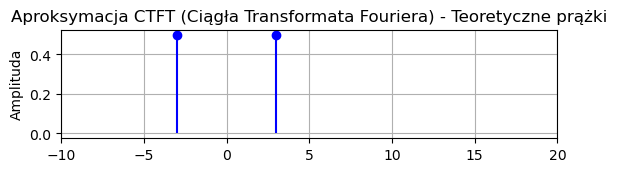

In [28]:
# CTFT
plt.subplot(3, 1, 1)
plt.stem(freq_ctft, amp_ctft, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.title("Aproksymacja CTFT (Ciągła Transformata Fouriera) - Teoretyczne prążki")
plt.xlim(-fs, 2*fs)
plt.ylabel("Amplituda")
plt.grid(True)

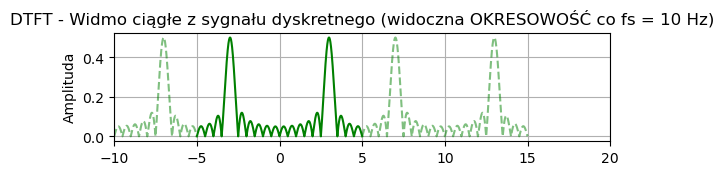

In [30]:
# DTFT
plt.subplot(3, 1, 2)
# Duplikujemy widmo DTFT ręcznie na wykresie, aby pokazać powtarzalność co fs poza zakresem [-fs/2, fs/2]
plt.plot(freq_dtft_shifted, X_dtft, 'g-')
plt.plot(freq_dtft_shifted + fs, X_dtft, 'g--', alpha=0.5) # Kopia +fs
plt.plot(freq_dtft_shifted - fs, X_dtft, 'g--', alpha=0.5) # Kopia -fs
plt.title("DTFT - Widmo ciągłe z sygnału dyskretnego (widoczna OKRESOWOŚĆ co fs = 10 Hz)")
plt.xlim(-fs, 2*fs)
plt.ylabel("Amplituda")
plt.grid(True)

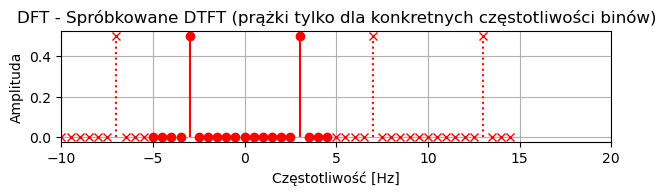

In [32]:
# DFT
plt.subplot(3, 1, 3)
plt.stem(freq_dft, X_dft, basefmt=" ", linefmt='r-', markerfmt='ro')
plt.stem(freq_dft + fs, X_dft, basefmt=" ", linefmt='r:', markerfmt='rx') # Kopia +fs
plt.stem(freq_dft - fs, X_dft, basefmt=" ", linefmt='r:', markerfmt='rx') # Kopia -fs
plt.title("DFT - Spróbkowane DTFT (prążki tylko dla konkretnych częstotliwości binów)")
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Amplituda")
plt.xlim(-fs, 2*fs)
plt.grid(True)

plt.tight_layout()
plt.show()

### Wpływ długości okna na rozdzielczość widma

In [35]:
# Generujemy sygnał będący sumą dwóch bardzo bliskich częstotliwości
f1 = 5.0   # Hz
f2 = 5.5   # Hz
fs2 = 50.0 # Hz

In [37]:
# Przypadek A: Krótkie okno (T = 1 sekunda)
T_short = 1.0
N_short = int(fs2 * T_short)
t_short = np.arange(N_short) / fs2
x_short = np.cos(2 * np.pi * f1 * t_short) + np.cos(2 * np.pi * f2 * t_short)

In [39]:
# Obliczamy DFT i zeropadded FFT (dla ładnego wykresu krzywej)
freq_short = np.fft.rfftfreq(N_short, 1/fs2)
X_short = np.abs(np.fft.rfft(x_short)) / (N_short/2)

freq_short_pad = np.fft.rfftfreq(N_pad, 1/fs2)
X_short_pad = np.abs(np.fft.rfft(x_short, n=N_pad)) / (N_short/2)

In [41]:
# Przypadek B: Długie okno (T = 4 sekundy)
T_long = 4.0
N_long = int(fs2 * T_long)
t_long = np.arange(N_long) / fs2
x_long = np.cos(2 * np.pi * f1 * t_long) + np.cos(2 * np.pi * f2 * t_long)

freq_long = np.fft.rfftfreq(N_long, 1/fs2)
X_long = np.abs(np.fft.rfft(x_long)) / (N_long/2)

freq_long_pad = np.fft.rfftfreq(N_pad, 1/fs2)
X_long_pad = np.abs(np.fft.rfft(x_long, n=N_pad)) / (N_long/2)

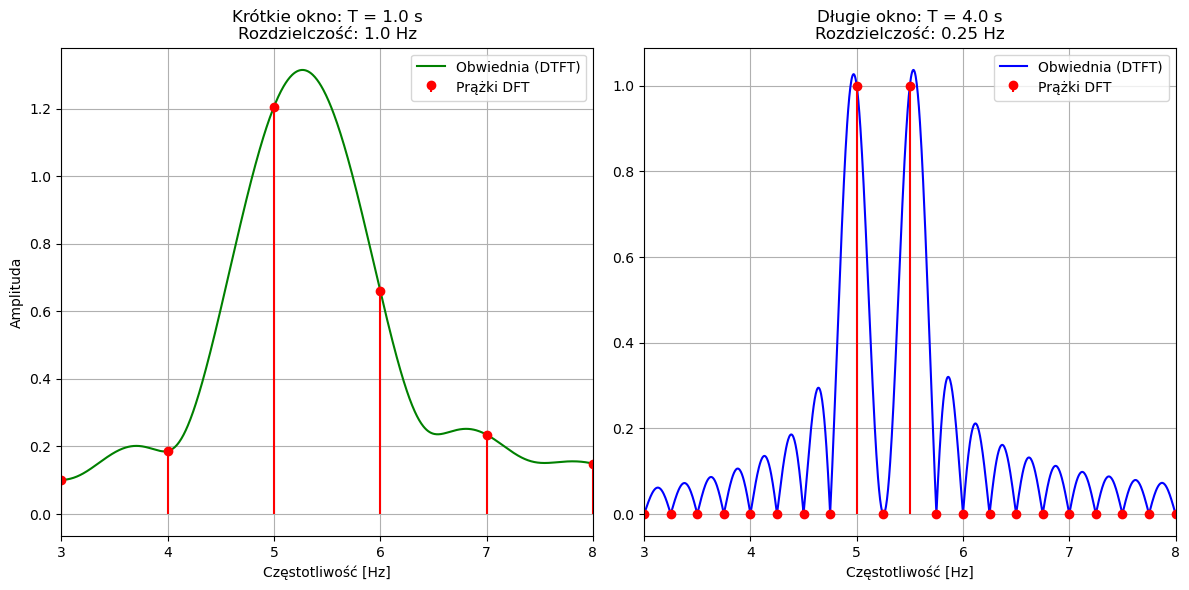

In [43]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(freq_short_pad, X_short_pad, 'g-', label="Obwiednia (DTFT)")
plt.stem(freq_short, X_short, linefmt='r-', markerfmt='ro', basefmt=" ", label="Prążki DFT")
plt.title(f"Krótkie okno: T = {T_short} s\nRozdzielczość: {1/T_short} Hz")
plt.xlim(3, 8)
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Amplituda")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(freq_long_pad, X_long_pad, 'b-', label="Obwiednia (DTFT)")
plt.stem(freq_long, X_long, linefmt='r-', markerfmt='ro', basefmt=" ", label="Prążki DFT")
plt.title(f"Długie okno: T = {T_long} s\nRozdzielczość: {1/T_long} Hz")
plt.xlim(3, 8)
plt.xlabel("Częstotliwość [Hz]")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()